# **Video Processing Week 1: Fondasi & Teknik CV Klasik**

Minggu ini kita akan mempelajari **pengolahan video frame-by-frame** dengan teknik-teknik klasik (non-AI) menggunakan OpenCV. Fokus utama adalah manipulasi video real-time maupun file, serta efek dasar yang sering digunakan dalam produksi video.

**Tujuan Pembelajaran:**

Di akhir sesi ini kita akan bisa:
- Membaca, menulis, dan menangkap video (file & webcam).
- Mengkonversi colorspace dan menerapkan filter dasar (blur, edge).
- Membuat efek *chroma key* (green screen) dengan mask warna.
- Melakukan *object tracking* menggunakan algoritma OpenCV (CSRT/KCF).
- (Opsional) Men-stabilkan video dengan fitur bawaan OpenCV.

> *This module is inspired by the development of last semester’s materials.* 

> **Versi modifikasi:** beberapa blok kode diubah ringan dengan efek visual berbeda seperti sepia, edge overlay, bilateral blur, dan mask smoothing.

## **Pengantar Video Processing**

### **Apa itu Video?**

**Video** adalah rangkaian gambar (frame) yang ditampilkan secara berurutan dengan kecepatan tertentu (frame rate).  
- Satuan video adalah **frame** (gambar individu)  
- **Frame rate** diukur dalam fps (frames per second) - umumnya 24, 30, atau 60 fps  
- Video bisa berasal dari file atau device seperti webcam  

Dalam pengolahan video, kita akan:
1. Membaca dan menulis file video
2. Memproses setiap frame secara individual
3. Menerapkan efek dan teknik khusus video
4. Menangkap video dari webcam untuk processing real-time

*Sebelum lanjut, kita coba import library yang akan kita butuhkan dulu*

**⚠️ PENTING: Install library `opencv-contrib-python`, bukan `opencv-python`. Fitur object detection hanya tersedia di library `opencv-contrib-python`**

In [1]:
# pip install opencv-contrib-python==4.11.0.86 numpy matplotlib ipykernel

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Mode aman: biarkan False jika ingin Run All tanpa membuka window kamera/video.
# Ubah True hanya saat ingin mencoba cell interaktif secara manual.
RUN_INTERACTIVE = False
MAX_FRAMES = 180


def show_rgb(title, image_bgr, figsize=(8, 5)):
    """Helper kecil untuk menampilkan frame BGR OpenCV di matplotlib."""
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


def apply_sepia(frame):
    """Efek sepia sederhana agar tampilan video berbeda dari grayscale biasa."""
    kernel = np.array([[0.272, 0.534, 0.131],
                       [0.349, 0.686, 0.168],
                       [0.393, 0.769, 0.189]])
    sepia = cv2.transform(frame, kernel)
    return np.clip(sepia, 0, 255).astype(np.uint8)


## Fundamental Video I/O (OpenCV)

Video hanyalah rangkaian gambar diam (disebut frames) yang ditampilkan secara berurutan dengan sangat cepat.

Ketika gambar-gambar ini ditampilkan dengan kecepatan tertentu, misalnya 24, 30, atau 60 gambar setiap detiknya, mata kita akan menangkapnya sebagai sebuah gerakan ilusi yang mulus. Kecepatan pemutaran ini disebut Frames Per Second (FPS).

Kita akan belajar cara menggunakan OpenCV untuk melakukan pengolahan video dari file dan dari kamera secara real-time.

### Membaca file video

Kita akan mencoba membuka file video menggunakan OpenCV dan menampilkan:
- frame pertama dan frame ke-n
- Video di dalam window terpisah

Dimensi Frame: (720, 1280, 3)


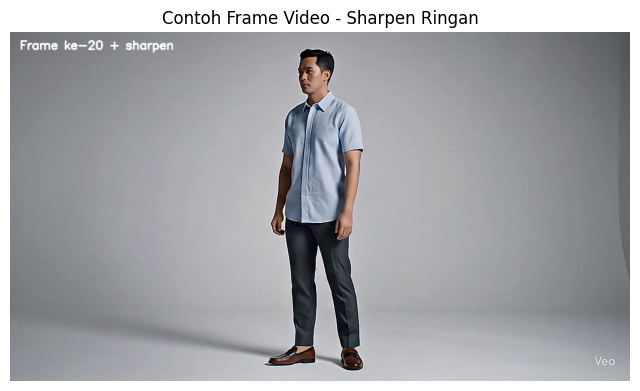

In [3]:
# Membaca satu frame dari video dan memberi efek detail ringan
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'man_walking.mp4')

cap = cv2.VideoCapture(PATH_VIDEO)
if cap.isOpened():
    # Membaca frame ke-n agar contoh tidak selalu frame pertama
    frame_at = 20
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_at - 1)

    ret, frame = cap.read()
    if ret:
        print(f"Dimensi Frame: {frame.shape}")

        # MODIFIKASI: frame dipertajam sedikit, lalu diberi teks nomor frame
        sharpen_kernel = np.array([[0, -1, 0],
                                   [-1, 5, -1],
                                   [0, -1, 0]])
        sharp_frame = cv2.filter2D(frame, -1, sharpen_kernel)
        cv2.putText(sharp_frame, f"Frame ke-{frame_at} + sharpen", (20, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        show_rgb("Contoh Frame Video - Sharpen Ringan", sharp_frame)
    else:
        print(f"Error: Gagal membaca frame dari {PATH_VIDEO}. Video mungkin kosong.")
else:
    print(f"Error: Tidak bisa membuka file video di '{PATH_VIDEO}'")
    print("Pastikan nama file dan path sudah benar, atau file tidak korup.")

cap.release()


In [4]:
# Menampilkan video dengan efek sepia + batas frame agar tidak berjalan terus
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'man_walking.mp4')
cap = cv2.VideoCapture(PATH_VIDEO)

if not RUN_INTERACTIVE:
    print("Cell playback dilewati agar Run All tidak membuka window. Ubah RUN_INTERACTIVE=True untuk mencoba.")
elif cap.isOpened():
    frame_count = 0
    while frame_count < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            print("Video selesai")
            break

        # MODIFIKASI: playback menggunakan efek sepia, bukan frame asli penuh
        sepia_frame = apply_sepia(frame)
        cv2.imshow('Video Playback - Sepia Effect', sepia_frame)
        frame_count += 1

        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
else:
    print(f"Error: Tidak bisa membuka file video di '{PATH_VIDEO}'")
    print("Pastikan nama file dan path sudah benar, atau file tidak korup.")

cap.release()
cv2.destroyAllWindows()


Cell playback dilewati agar Run All tidak membuka window. Ubah RUN_INTERACTIVE=True untuk mencoba.


### Menangkap Gambar dari Webcam

Untuk menangkap video dari webcam, kita bisa menggunakan `cv2.VideoCapture(0)`, di mana `0` adalah indeks default untuk webcam pertama. Jika Anda memiliki beberapa kamera, Anda bisa mencoba `1`, `2`, dll.

In [5]:
# Menangkap gambar dari webcam dengan mirror effect dan label kecil
if not RUN_INTERACTIVE:
    print("Cell webcam dilewati agar Run All aman. Ubah RUN_INTERACTIVE=True lalu jalankan cell ini saja.")
else:
    cap = cv2.VideoCapture(0)

    if cap.isOpened():
        print("Webcam berhasil diakses. Tekan 'q' untuk keluar.")
        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal membaca frame dari webcam")
                break

            # MODIFIKASI: frame dibuat mirror dan diberi blur tipis agar lebih halus
            frame = cv2.flip(frame, 1)
            frame = cv2.GaussianBlur(frame, (3, 3), 0)
            cv2.putText(frame, "Mirror + Soft Blur", (15, 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.imshow('Webcam Live - Modified', frame)
            frame_count += 1

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: Tidak bisa mengakses webcam")
        print("Pastikan webcam terhubung dan tidak digunakan aplikasi lain")

    cap.release()
    cv2.destroyAllWindows()


Cell webcam dilewati agar Run All aman. Ubah RUN_INTERACTIVE=True lalu jalankan cell ini saja.


### Menyimpan/menulis ke file video baru

Untuk menyimpan video yang telah diproses, kita dapat menggunakan `cv2.VideoWriter`. Kita perlu menentukan nama file output, codec video, frame rate, dan ukuran frame.

Kita akan mencoba mengubah video menjadi grayscale dan menyimpannya ke file baru.

In [6]:
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'man_walking.mp4')
OUTPUT_VIDEO = os.path.join(os.getcwd(), 'data', 'output_sepia_edge.mp4')

# Baca video input
cap = cv2.VideoCapture(PATH_VIDEO)

if cap.isOpened():
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (frame_width, frame_height))

    print(f"Menyimpan video efek sepia-edge ke: {OUTPUT_VIDEO}")
    print(f"Resolusi: {frame_width}x{frame_height}, FPS: {fps}")

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Proses selesai!")
            break

        # MODIFIKASI: bukan grayscale polos, tetapi sepia yang digabung dengan tepi Canny
        sepia_frame = apply_sepia(frame)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(gray, 80, 160)
        edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
        final_frame = cv2.addWeighted(sepia_frame, 0.85, edges_bgr, 0.25, 0)

        out.write(final_frame)
        frame_count += 1

        if RUN_INTERACTIVE:
            cv2.imshow('Processing Video - Sepia Edge', final_frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Video modifikasi berhasil disimpan di: {OUTPUT_VIDEO}")
else:
    print(f"Error: Tidak bisa membuka file video di '{PATH_VIDEO}'")


Menyimpan video efek sepia-edge ke: c:\Users\ASUS\Semester 6\Pengolahan Citra\Pengolahan_Multimedia\data\output_sepia_edge.mp4
Resolusi: 1280x720, FPS: 24
Proses selesai!
Video modifikasi berhasil disimpan di: c:\Users\ASUS\Semester 6\Pengolahan Citra\Pengolahan_Multimedia\data\output_sepia_edge.mp4


## Manipulasi Frame Dasar

Setelah berhasil membaca dan menulis video, kita akan mempelajari teknik-teknik dasar untuk memanipulasi setiap frame dalam video. Manipulasi frame adalah fondasi dari semua efek video processing:

### **Konversi Colorspace**
Mengubah representasi warna frame (BGR → Grayscale, BGR → HSV, dll) untuk kebutuhan analisis atau efek tertentu.

**1. BGR to Grayscale:**
- Mengubah gambar berwarna menjadi hitam-putih
- Menghilangkan informasi warna, hanya menyimpan intensitas cahaya
- Mengurangi 3 channel (Blue, Green, Red) menjadi 1 channel saja
- Berguna untuk analisis bentuk, deteksi tepi, dan mengurangi kompleksitas komputasi

**2. BGR to HSV:**
- **H (Hue)**: Jenis warna (0-179° dalam OpenCV)
- **S (Saturation)**: Tingkat kejenuhan/kemurnian warna (0-255)
- **V (Value)**: Kecerahan/intensitas warna (0-255)
- Lebih intuitif untuk pemrosesan berdasarkan warna tertentu
- Sangat berguna untuk chroma keying (green screen) dan color-based object detection

In [7]:
# Konversi frame webcam ke Grayscale + CLAHE agar kontrasnya berbeda
if not RUN_INTERACTIVE:
    print("Cell grayscale webcam dilewati agar Run All aman.")
else:
    cap = cv2.VideoCapture(0)

    if cap.isOpened():
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal membaca frame dari webcam")
                break

            gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            contrast_gray = clahe.apply(gray_frame)
            cv2.imshow('Webcam - Grayscale CLAHE', contrast_gray)
            frame_count += 1

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: Tidak bisa mengakses webcam")
        print("Pastikan webcam terhubung dan tidak digunakan aplikasi lain")

    cap.release()
    cv2.destroyAllWindows()


Cell grayscale webcam dilewati agar Run All aman.


In [8]:
# Konversi frame webcam ke HSV lalu visualisasi channel Hue saja
if not RUN_INTERACTIVE:
    print("Cell HSV webcam dilewati agar Run All aman.")
else:
    cap = cv2.VideoCapture(0)

    if cap.isOpened():
        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal membaca frame dari webcam")
                break

            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            hue_channel = hsv_frame[:, :, 0]
            hue_color = cv2.applyColorMap(hue_channel, cv2.COLORMAP_TURBO)
            cv2.imshow('Webcam Live - Hue Color Map', hue_color)
            frame_count += 1

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: Tidak bisa mengakses webcam")
        print("Pastikan webcam terhubung dan tidak digunakan aplikasi lain")

    cap.release()
    cv2.destroyAllWindows()


Cell HSV webcam dilewati agar Run All aman.


### **Filter Dasar**

Setelah konversi colorspace, kita akan mempelajari filter dasar yang sering digunakan dalam video processing:

**1. Blur Filter:**
- Menghaluskan gambar dengan mengurangi noise dan detail halus
- Membuat efek buram dengan merata-ratakan nilai pixel di sekitarnya
- Berguna untuk preprocessing sebelum deteksi objek atau mengurangi gangguan
- Jenis blur: Gaussian Blur, Motion Blur, dan Median Blur

**2. Canny Edge Detection:**
- Mendeteksi tepi/garis batas objek dalam gambar
- Mengubah gambar menjadi representasi garis putih pada latar belakang hitam
- Sangat berguna untuk analisis bentuk, kontur objek, dan segmentasi
- Menggunakan algoritma gradien untuk menemukan perubahan intensitas yang tajam

In [9]:
# Bilateral Blur pada webcam: blur halus tetapi tepi objek tetap lebih jelas
if not RUN_INTERACTIVE:
    print("Cell blur webcam dilewati agar Run All aman.")
else:
    cap = cv2.VideoCapture(0)

    if cap.isOpened():
        print("Webcam berhasil diakses. Tekan 'q' untuk keluar.")
        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal membaca frame dari webcam")
                break

            # MODIFIKASI: dari average blur menjadi bilateral blur
            blurred = cv2.bilateralFilter(frame, 13, 75, 75)
            cv2.putText(blurred, "Bilateral Blur", (15, 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.imshow('Bilateral Blur', blurred)
            frame_count += 1

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: Tidak bisa mengakses webcam")

    cap.release()
    cv2.destroyAllWindows()


Cell blur webcam dilewati agar Run All aman.


In [10]:
# Canny Edge Detection pada webcam dengan overlay ke frame asli
if not RUN_INTERACTIVE:
    print("Cell Canny webcam dilewati agar Run All aman.")
else:
    cap = cv2.VideoCapture(0)

    if cap.isOpened():
        frame_count = 0
        while frame_count < MAX_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("Error: Gagal membaca frame dari webcam")
                break

            # MODIFIKASI: blur dahulu agar noise tepi berkurang, lalu edge dioverlay
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.GaussianBlur(gray, (5, 5), 0)
            edges = cv2.Canny(gray, 60, 140)
            edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
            overlay = cv2.addWeighted(frame, 0.75, edges_bgr, 0.45, 0)
            cv2.imshow('Canny Edge Overlay', overlay)
            frame_count += 1

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    else:
        print("Error: Tidak bisa mengakses webcam")
        print("Pastikan webcam terhubung dan tidak digunakan aplikasi lain")

    cap.release()
    cv2.destroyAllWindows()


Cell Canny webcam dilewati agar Run All aman.


## Chroma Keying (Efek "Green Screen")

Chroma keying adalah teknik mengganti background berdasarkan warna tertentu (biasanya hijau atau biru) dengan gambar/video lain. Teknik ini sangat populer dalam industri film dan broadcasting.

**Konsep Dasar:**
- **Background khusus**: Objek direkam di depan layar berwarna solid (green screen/blue screen)
- **Color separation**: Algoritma memisahkan warna background dari foreground
- **Compositing**: Background diganti dengan gambar/video yang diinginkan

**Catatan**:
- Hindari objek yang berwarna hijau agar tidak ikut ter-mask
- Kualitas hasil tergantung pada kualitas green screen dan pencahayaan

**Langkah-langkah Chroma Keying:**

### **1. Membuat Mask Berdasarkan Rentang Warna (Hijau)**
- Konversi frame ke HSV colorspace untuk deteksi warna yang lebih akurat
- Tentukan rentang nilai HSV untuk warna hijau (Hue: 40-80, Saturation: tinggi, Value: tinggi)
- Gunakan `cv2.inRange()` untuk membuat binary mask (putih = hijau, hitam = bukan hijau)
- Terapkan **morphological operations** untuk membersihkan mask:
    - **Erosi**: menghilangkan titik-titik noise kecil
    - **Dilasi**: menutup lubang-lubang kecil di dalam mask
    - Hasil: mask yang lebih bersih dan solid

In [11]:
# Membuat mask berdasarkan rentang warna hijau dengan smoothing tambahan
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'green_screen_sample.mp4')
cap = cv2.VideoCapture(PATH_VIDEO)

if not RUN_INTERACTIVE:
    print("Cell chroma mask dilewati agar Run All tidak membuka window.")
elif cap.isOpened():
    frame_count = 0
    while frame_count < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            print("Video selesai atau tidak bisa membaca frame")
            break

        hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # MODIFIKASI: range hijau sedikit dipersempit agar mask lebih selektif
        lower_green = np.array([38, 55, 45])
        upper_green = np.array([85, 255, 255])
        mask = cv2.inRange(hsv_frame, lower_green, upper_green)

        kernel = np.ones((7, 7), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.GaussianBlur(mask, (9, 9), 0)

        cv2.imshow('Original Frame', frame)
        cv2.imshow('HSV Frame', hsv_frame)
        cv2.imshow('Green Mask - Smooth', mask)
        frame_count += 1

        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
else:
    print(f"Error: Tidak bisa membuka file video di '{PATH_VIDEO}'")
    print("Pastikan file 'green_screen_sample.mp4' ada di folder 'data'")

cap.release()
cv2.destroyAllWindows()


Cell chroma mask dilewati agar Run All tidak membuka window.


### **2. Mengganti Area Mask dengan Gambar atau Video Lain**
- Load 2 video: Green screen dan background replacement
- Deteksi hijau: Konversi ke HSV, buat mask untuk area hijau dengan cv2.inRange()
- Bersihkan mask: Morphological operations (OPEN & CLOSE) untuk hapus noise
- Pisahkan objek & background: bitwise_and() dengan mask asli dan mask terbalik
- Gabungkan hasil: cv2.add() foreground + background = green screen diganti

In [12]:
# Chroma Keying: Mengganti green screen dengan video lain + feather blend
PATH_VIDEO_GREEN = os.path.join(os.getcwd(), 'data', 'green_screen_sample.mp4')
PATH_VIDEO_BG = os.path.join(os.getcwd(), 'data', 'man_walking.mp4')

cap_green = cv2.VideoCapture(PATH_VIDEO_GREEN)
cap_bg = cv2.VideoCapture(PATH_VIDEO_BG)

if not RUN_INTERACTIVE:
    print("Cell chroma keying dilewati agar Run All aman.")
elif cap_green.isOpened() and cap_bg.isOpened():
    print("Kedua video berhasil dibuka. Tekan 'q' untuk keluar.")
    frame_width = int(cap_green.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap_green.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = 0

    while frame_count < MAX_FRAMES:
        ret_green, frame_green = cap_green.read()
        ret_bg, frame_bg = cap_bg.read()
        if not ret_green or not ret_bg:
            print("Salah satu video source atau green screen selesai")
            break

        frame_bg = cv2.resize(frame_bg, (frame_width, frame_height))
        hsv_frame = cv2.cvtColor(frame_green, cv2.COLOR_BGR2HSV)
        lower_green = np.array([38, 55, 45])
        upper_green = np.array([85, 255, 255])
        mask = cv2.inRange(hsv_frame, lower_green, upper_green)

        # MODIFIKASI: pinggir mask dibuat halus agar transisi foreground-background tidak kasar
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        soft_mask = cv2.GaussianBlur(mask, (15, 15), 0).astype(np.float32) / 255.0
        soft_mask_3ch = cv2.merge([soft_mask, soft_mask, soft_mask])

        foreground = frame_green.astype(np.float32) * (1 - soft_mask_3ch)
        background = frame_bg.astype(np.float32) * soft_mask_3ch
        result = np.clip(foreground + background, 0, 255).astype(np.uint8)

        cv2.imshow('Chroma Keying - Feather Blend', result)
        cv2.imshow('Soft Mask', (soft_mask * 255).astype(np.uint8))
        frame_count += 1

        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
else:
    print("Error: Tidak bisa membuka salah satu file video")
    print("Pastikan green_screen_sample.mp4 dan man_walking.mp4 ada di folder data")

cap_green.release()
cap_bg.release()
cv2.destroyAllWindows()


Cell chroma keying dilewati agar Run All aman.


## Object Tracking (OpenCV Trackers)

Object tracking adalah teknik untuk mengikuti pergerakan objek tertentu di dalam video secara otomatis. Setelah kita memilih objek di frame pertama, algoritma tracker akan terus mengikuti objek tersebut di frame-frame berikutnya.

**Konsep Dasar:**
- **Inisialisasi**: Pilih objek yang ingin di-track dengan menggambar bounding box (kotak pembatas)
- **Tracking**: Algoritma mencari lokasi objek di frame berikutnya berdasarkan fitur visual
- **Update**: Posisi bounding box diperbarui mengikuti pergerakan objek

### Pengenalan Algoritma Tracker
**Jenis-jenis Tracker OpenCV:**

#### **1. CSRT (Channel and Spatial Reliability Tracker)**
- **Akurasi tinggi**: Sangat baik untuk objek yang bergerak lambat hingga sedang
- **Robust**: Tahan terhadap perubahan bentuk, rotasi, dan sebagian occlusion
- **Kecepatan**: Relatif lambat dibanding tracker lain
- **Use case**: Tracking wajah, kendaraan, objek dengan detail tinggi

#### **2. KCF (Kernelized Correlation Filters)**
- **Kecepatan tinggi**: Sangat cepat dalam komputasi
- **Akurasi sedang**: Baik untuk objek bergerak cepat tapi bentuk relatif stabil
- **Keterbatasan**: Kurang baik menangani perubahan skala dan rotasi drastis
- **Use case**: Tracking objek bergerak cepat, aplikasi real-time

#### **3. Tracker Lainnya:**
- **BOOSTING**: Tracker pertama, akurasi rendah tapi cepat
- **MIL**: Lebih robust dari BOOSTING, menangani noise dengan baik
- **TLD**: Baik untuk long-term tracking, bisa "menemukan kembali" objek yang hilang
- **MEDIANFLOW**: Sangat cepat, cocok untuk objek bergerak halus dan predictable

**Cara Kerja Umum:**
1. **Pilih ROI (Region of Interest)**: User menggambar kotak di sekitar objek
2. **Ekstraksi fitur**: Tracker mempelajari karakteristik visual objek (warna, tekstur, bentuk)
3. **Prediksi**: Berdasarkan frame sebelumnya, prediksi lokasi objek di frame berikutnya
4. **Koreksi**: Cari area yang paling mirip dengan template objek
5. **Update**: Perbarui posisi bounding box dan template objek

### Praktik: Memilih objek (via ROI) dan membiarkan tracker mengikutinya

In [13]:
# Object Tracking menggunakan CSRT Tracker + jejak titik tengah objek
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'man_walking.mp4')
cap = cv2.VideoCapture(PATH_VIDEO)

if not RUN_INTERACTIVE:
    print("Cell object tracking dilewati agar Run All tidak menunggu pemilihan ROI.")
else:
    tracker = cv2.TrackerCSRT_create()

    if cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Error: Tidak bisa membaca frame pertama")
        else:
            bbox = cv2.selectROI('Pilih objek untuk tracking', frame, False)
            cv2.destroyWindow('Pilih objek untuk tracking')
            tracker.init(frame, bbox)
            trail_points = []
            frame_count = 0
            print("Tracking dimulai. Tekan 'q' untuk keluar.")

            while frame_count < MAX_FRAMES:
                ret, frame = cap.read()
                if not ret:
                    print("Video selesai")
                    break

                success, bbox = tracker.update(frame)
                if success:
                    x, y, w, h = [int(v) for v in bbox]
                    center = (x + w // 2, y + h // 2)
                    trail_points.append(center)
                    trail_points = trail_points[-25:]

                    # MODIFIKASI: tampilkan jejak tracking, bukan hanya kotak objek
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 180, 255), 2)
                    for i in range(1, len(trail_points)):
                        cv2.line(frame, trail_points[i - 1], trail_points[i], (255, 255, 0), 2)
                    cv2.putText(frame, "Tracking + Motion Trail", (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 180, 255), 2)
                else:
                    cv2.putText(frame, "Tracking gagal", (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

                cv2.imshow('Object Tracking - Trail', frame)
                frame_count += 1
                if cv2.waitKey(30) & 0xFF == ord('q'):
                    break
    else:
        print(f"Error: Tidak bisa membuka file video di '{PATH_VIDEO}'")

    cap.release()
    cv2.destroyAllWindows()


Cell object tracking dilewati agar Run All tidak menunggu pemilihan ROI.


### 🔎 Eksplorasi

- Cobalah melakukan Object Detection melalui Webcam Anda secara real-time
- Cobalah menggunakan algoritma tracker lainnya dan bandingkan hasilnya.

Hint: ubah bagian kode `tracker = cv2.TrackerCSRT_create()`

## Video Stabilization (Opsional / Pengayaan)

Video stabilization adalah teknik untuk mengurangi  getaran dalam video, menghasilkan footage yang lebih halus dan stabil untuk pengalaman menonoton yang lebih baik.

### Pengenalan singkat konsep stabilisasi video (feature matching & warping).

**Prinsip Kerja Video Stabilization:**

#### **1. Feature Detection & Matching**
- **Deteksi keypoints**: Menggunakan `cv2.goodFeaturesToTrack()` untuk menemukan titik-titik karakteristik yang mudah dikenali
- **Feature matching**: Mencocokkan keypoints yang sama antar frame berurutan
- **Tracking motion**: Menggunakan `cv2.calcOpticalFlowPyrLK()` untuk melacak pergerakan fitur-fitur tersebut

#### **2. Motion Estimation**
- **Transformasi geometris**: Menghitung bagaimana frame bergerak relatif terhadap frame sebelumnya
- **Parameter motion**: Translation (x,y), rotation, dan scaling menggunakan `cv2.estimateAffinePartial2D()`
- **Motion vector**: Mendapatkan vektor perpindahan untuk setiap frame

#### **3. Trajectory Smoothing**
- **Raw trajectory**: Kumpulan semua motion vector (biasanya bergelombang/noisy)
- **Smooth trajectory**: Aplikasi moving average atau filter lain untuk menghaluskan pergerakan
- **Stabilization**: Selisih antara raw dan smooth trajectory menjadi koreksi yang dibutuhkan

#### **4. Frame Correction & Warping**
- **Geometric transformation**: Menerapkan koreksi menggunakan `cv2.warpAffine()` atau `cv2.warpPerspective()`
- **Frame warping**: Merotasi, mentranslasi, atau menskalakan frame untuk mengkompensasi goyangan
- **Border handling**: Mengatasi area kosong akibat transformasi (crop, interpolation, atau border replication)

**Kelebihan & Keterbatasan:**
- ✅ **Efektif**: Mengurangi goyangan secara signifikan untuk kebanyakan kasus
- ✅ **Non-destructive**: Tidak merusak kualitas visual secara drastis
- ❌ **Cropping**: Memerlukan sedikit crop di tepi frame untuk ruang koreksi
- ❌ **Rolling shutter**: Kurang efektif untuk distorsi rolling shutter kamera smartphone

In [14]:
# Video Stabilization - Optical Flow + crop border ringan
PATH_VIDEO = os.path.join(os.getcwd(), 'data', 'unstabilized_video.mp4')
OUTPUT_VIDEO = os.path.join(os.getcwd(), 'data', 'stabilized_video_modified.mp4')

cap = cv2.VideoCapture(PATH_VIDEO)
if not cap.isOpened():
    print(f"Error: Tidak bisa membuka video di '{PATH_VIDEO}'")
else:
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

    _, prev = cap.read()
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    transforms = np.zeros((max(n_frames - 1, 1), 3), np.float32)

    for i in range(n_frames - 1):
        success, curr = cap.read()
        if not success:
            break
        curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)
        prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01,
                                           minDistance=30, blockSize=3)
        curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)
        idx = np.where(status == 1)[0]
        prev_pts = prev_pts[idx]
        curr_pts = curr_pts[idx]

        if len(prev_pts) >= 8:
            m, _ = cv2.estimateAffinePartial2D(prev_pts, curr_pts)
        else:
            m = None
        if m is None:
            dx = dy = da = 0
        else:
            dx = m[0, 2]
            dy = m[1, 2]
            da = np.arctan2(m[1, 0], m[0, 0])
        transforms[i] = [dx, dy, da]
        prev_gray = curr_gray

    trajectory = np.cumsum(transforms, axis=0)
    radius = 15
    smoothed = np.copy(trajectory)
    for j in range(3):
        smoothed[:, j] = np.convolve(trajectory[:, j], np.ones(radius) / radius, mode='same')
    difference = smoothed - trajectory
    transforms_smooth = transforms + difference

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    for i in range(n_frames - 1):
        success, frame = cap.read()
        if not success:
            break
        dx, dy, da = transforms_smooth[i]
        m = np.array([[np.cos(da), -np.sin(da), dx],
                      [np.sin(da),  np.cos(da), dy]], dtype=np.float32)
        stabilized = cv2.warpAffine(frame, m, (w, h))

        # MODIFIKASI: crop sedikit lalu resize untuk mengurangi border hitam
        border = 12
        cropped = stabilized[border:h-border, border:w-border]
        stabilized = cv2.resize(cropped, (w, h))
        out.write(stabilized)

        if RUN_INTERACTIVE:
            cv2.imshow('Original', frame)
            cv2.imshow('Stabilized Modified', stabilized)
            if cv2.waitKey(20) & 0xFF == ord('q'):
                break

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Video stabilisasi modifikasi disimpan di: {OUTPUT_VIDEO}")


Video stabilisasi modifikasi disimpan di: c:\Users\ASUS\Semester 6\Pengolahan Citra\Pengolahan_Multimedia\data\stabilized_video_modified.mp4


## **Kesimpulan**

Dalam notebook **Video Processing Week 1** ini, kita telah mempelajari fondasi pengolahan video menggunakan teknik Computer Vision klasik (non-AI) dengan OpenCV. Berikut adalah ringkasan pencapaian pembelajaran:

### **🎯 Pencapaian Utama:**

**1. Video I/O Fundamental**
- ✅ Berhasil membaca dan menulis file video dengan `cv2.VideoCapture()` dan `cv2.VideoWriter()`
- ✅ Menangkap video real-time dari webcam untuk processing langsung
- ✅ Memahami konsep frame, frame rate (fps), dan struktur video sebagai sekuens gambar

**2. Manipulasi Frame Dasar**
- ✅ Konversi colorspace (BGR ↔ Grayscale, BGR ↔ HSV) untuk berbagai kebutuhan analisis
- ✅ Penerapan filter dasar: Blur untuk smoothing dan Canny Edge Detection untuk deteksi tepi
- ✅ Preprocessing frame untuk persiapan teknik lanjutan

**3. Chroma Keying (Green Screen)**
- ✅ Implementasi teknik green screen menggunakan HSV color masking
- ✅ Pemisahan foreground-background berdasarkan rentang warna tertentu
- ✅ Morphological operations untuk membersihkan noise pada mask
- ✅ Compositing dua video untuk efek replacement background

**4. Object Tracking**
- ✅ Penerapan algoritma CSRT dan KCF tracker untuk mengikuti objek bergerak
- ✅ Inisialisasi ROI (Region of Interest) dan tracking otomatis sepanjang video
- ✅ Perbandingan performa berbagai algoritma tracker OpenCV

**5. Video Stabilization (Pengayaan)**
- ✅ Implementasi teknik stabilisasi menggunakan Optical Flow
- ✅ Feature detection, motion estimation, trajectory smoothing, dan frame warping
- ✅ Koreksi goyangan kamera untuk menghasilkan video yang lebih stabil

### **💡 Insight Teknis:**

- **Colorspace HSV** terbukti sangat efektif untuk color-based processing seperti chroma keying
- **Morphological operations** penting untuk membersihkan hasil segmentasi warna
- **CSRT tracker** memberikan akurasi tinggi untuk objek bergerak lambat-sedang
- **Video stabilization** memerlukan trade-off antara kestabilan dan cropping area

### **🚀 Aplikasi Praktis:**

Teknik-teknik yang dipelajari dapat diaplikasikan untuk:
- **Content Creation**: Green screen effects, video editing
- **Surveillance**: Object tracking untuk keamanan
- **Broadcasting**: Real-time video effects dan stabilization
- **Research**: Preprocessing untuk computer vision tasks lanjutan

Notebook ini memberikan fondasi yang solid untuk eksplorasi lebih lanjut ke teknik video processing yang lebih advanced, termasuk deep learning dan AI-based video analysis.